<a href="https://colab.research.google.com/github/aavarela/SPBD_Labs/blob/main/projeto2/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 2 Development
This work was carried out by Afonso Varela (73544) and Gonçalo Dionísio (73638), with the help of Google Gemini 3 Pro (AI agent).

#Environment configuration
* Prepare pyspark
* Install & launch Kafka
* Start the Kafka publisher

In [1]:
#@title Uninstall dataproc-spark-connect 1.0.1 and current pyspark (if any) and install 3.5.7
!pip uninstall -y dataproc-spark-connect
!pip uninstall -y pyspark
!pip install pyspark==3.5.7

Found existing installation: dataproc-spark-connect 1.0.1
Uninstalling dataproc-spark-connect-1.0.1:
  Successfully uninstalled dataproc-spark-connect-1.0.1
Found existing installation: pyspark 4.0.1
Uninstalling pyspark-4.0.1:
  Successfully uninstalled pyspark-4.0.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.4/317.4 MB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 18.1 MB/s eta 0:00:00
  Created wheel for pyspark: filename=pyspark-3.5.7-py2.py3-none-any.whl size=317907716 sha256=cd381abc12d85284d37291fa105e30b5b75a1541438b19c4e57ee286f8912fe8
  Stored in directory: /root/.cache/pip/wheels/f2/d3/02/10ad17f2eeb2cb9c800e320c8ca9ac87d0df8fe3adb8af7e95
Successfully built pyspark
  Attempting uninstall: py4j
    Found existing installation: py4j 0.10.9.9
    Uninstalling py4j-0.10.9.9:
      Successfully uninstalled py4j-0.10.9.9


In [9]:
#@title Download 1% sample (if not already downloaded)
!wget -q -O taxi_rides_1pc.csv.gz https://www.dropbox.com/scl/fi/v8ei5laqcalrx30z3lsty/taxi_rides_1pc.csv.gz?rlkey=q1lq7l56c4j97h9kymsdroau5&st=iurdwnwj&dl=0

In [3]:
#@title Install & Launch Kafka
%%bash
KAFKA_VERSION=3.7.2
KAFKA=kafka_2.12-$KAFKA_VERSION
wget -q -O /tmp/$KAFKA.tgz https://dlcdn.apache.org/kafka/$KAFKA_VERSION/$KAFKA.tgz
tar xfz /tmp/$KAFKA.tgz
wget -q -O $KAFKA/config/server1.properties - https://github.com/smduarte/spbd-2526/raw/refs/heads/main/docs/labs/projs/server1.properties

UUID=`$KAFKA/bin/kafka-storage.sh random-uuid`
$KAFKA/bin/kafka-storage.sh format -t $UUID -c $KAFKA/config/server1.properties
$KAFKA/bin/kafka-server-start.sh -daemon $KAFKA/config/server1.properties

Formatting /tmp/kraft-combined-logs with metadata.version 3.7-IV4.


In [10]:
#@title Start Kafka publisher
!pip --quiet install kafka-python dataclasses
!wget -q -O kafka-publisher.py https://raw.githubusercontent.com/smduarte/spbd-2526/refs/heads/main/docs/labs/projs/kafka-publisher.py

!nohup python kafka-publisher.py --topic taxis_json --speedup 60 --filename taxi_rides_1pc.csv.gz 2> /dev/null &

# Data collection

In [50]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

spark = SparkSession \
    .builder \
    .appName('Kafka Spark Structured Streaming Example') \
    .config('spark.jars.packages', 'org.apache.spark:spark-sql-kafka-0-10_2.12:3.5.7') \
    .getOrCreate()

lines = spark \
  .readStream \
  .format('kafka') \
  .option('kafka.bootstrap.servers', 'localhost:9092') \
  .option('subscribe', 'taxis_json') \
  .option('startingOffsets', 'earliest') \
  .load() \
  .selectExpr('CAST(value AS STRING)')

# Define a StructType named taxi_ride_schema
taxi_ride_schema = StructType([
    StructField("medallion", StringType(), True),
    StructField("pickup_datetime", TimestampType(), True),
    StructField("dropoff_datetime", TimestampType(), True),
    StructField("fare_amount", DoubleType(), True),
    StructField("tip_amount", DoubleType(), True),
    StructField("trip_distance", DoubleType(), True),
    StructField("pickup_latitude", DoubleType(), True),
    StructField("pickup_longitude", DoubleType(), True),
    StructField("dropoff_latitude", DoubleType(), True),
    StructField("dropoff_longitude", DoubleType(), True),
    StructField("pickup_grid_x", IntegerType(), True),
    StructField("pickup_grid_y", IntegerType(), True),
    StructField("dropoff_grid_x", IntegerType(), True),
    StructField("dropoff_grid_y", IntegerType(), True)
])

# Apply the from_json function to parse the JSON strings
parsed_stream = lines.withColumn("parsed_value", from_json(col("value"), taxi_ride_schema))

# Select all fields from the parsed_value struct and project them directly
structured_stream = parsed_stream.select(col("parsed_value.*"))

print("Defined taxi_ride_schema and parsed Kafka stream into structured_stream.")
#structured_stream.printSchema()

MIN_LON = -74.916578
MAX_LAT = 41.47718278
LON_DELTA = 0.005986
LAT_DELTA = 0.004491556

processed_stream = structured_stream \
    .withColumn("pickup_grid_x", floor((MAX_LAT - col("pickup_latitude")) / LAT_DELTA)) \
    .withColumn("pickup_grid_y", floor((col("pickup_longitude") - MIN_LON) / LON_DELTA)) \
    .withColumn("dropoff_grid_x", floor((MAX_LAT - col("dropoff_latitude")) / LAT_DELTA)) \
    .withColumn("dropoff_grid_y", floor((col("dropoff_longitude") - MIN_LON) / LON_DELTA)) \
    .filter(
        (col("pickup_latitude").isNotNull()) & (col("pickup_longitude").isNotNull()) & \
        (col("dropoff_latitude").isNotNull()) & (col("dropoff_longitude").isNotNull()) & \
        (col("pickup_grid_x").between(0, 299)) & (col("pickup_grid_y").between(0, 299)) & \
        (col("dropoff_grid_x").between(0, 299)) & (col("dropoff_grid_y").between(0, 299)) & \
        (col("trip_distance") > 0)
    ) \
    .withColumn("trip_profit", col("fare_amount") + col("tip_amount"))

print("Streaming data prepared with grid coordinates, filtered, and trip profit calculated.")
#processed_stream.printSchema()

processed_stream_with_pickup_watermark = processed_stream.withWatermark("pickup_datetime", "10 minutes")
processed_stream_with_dropoff_watermark = processed_stream.withWatermark("dropoff_datetime", "10 minutes")

print("Watermarks applied to processed_stream based on pickup_datetime and dropoff_datetime.")
#processed_stream_with_pickup_watermark.printSchema()
#processed_stream_with_dropoff_watermark.printSchema()

average_profit_per_area_stream = processed_stream_with_dropoff_watermark \
    .groupBy(
        window(col("dropoff_datetime"), "15 minutes"),
        col("pickup_grid_x"),
        col("pickup_grid_y")
    ) \
    .agg(avg("trip_profit").alias("average_trip_profit"))

print("Calculated streaming average profit per area.")
#average_profit_per_area_stream.printSchema()

dropoffs_for_empty = processed_stream_with_dropoff_watermark.select(
    col("medallion").alias("d_medallion"),
    col("dropoff_datetime").alias("d_time"),
    col("dropoff_grid_x").alias("d_grid_x"),
    col("dropoff_grid_y").alias("d_grid_y")
)

pickups_for_empty = processed_stream_with_pickup_watermark.select(
    col("medallion").alias("p_medallion"),
    col("pickup_datetime").alias("p_time"),
    col("pickup_grid_x").alias("p_grid_x"),
    col("pickup_grid_y").alias("p_grid_y")
)

empty_taxis_identification = dropoffs_for_empty.join(
    pickups_for_empty,
    expr("""
        d_medallion = p_medallion AND
        d_grid_x = p_grid_x AND
        d_grid_y = p_grid_y AND
        p_time BETWEEN d_time AND d_time + INTERVAL 30 MINUTES
    """),
    "leftOuter"
)

filtered_empty_taxis = empty_taxis_identification.filter(col("p_medallion").isNull())

empty_taxis_per_area_stream = filtered_empty_taxis \
    .groupBy(
        window(col("d_time"), "15 minutes"),
        col("d_grid_x"),
        col("d_grid_y")
    ) \
    .agg(count(col("d_medallion")).alias("empty_taxi_count"))

print("Calculated streaming number of empty taxis per area.")
#empty_taxis_per_area_stream.printSchema()

area_metrics_stream = average_profit_per_area_stream.join(
    empty_taxis_per_area_stream,
    (
        (average_profit_per_area_stream.window == empty_taxis_per_area_stream.window) &
        (average_profit_per_area_stream.pickup_grid_x == empty_taxis_per_area_stream.d_grid_x) &
        (average_profit_per_area_stream.pickup_grid_y == empty_taxis_per_area_stream.d_grid_y)
    ),
    "leftOuter" # Changed from inner to leftOuter to ensure data flow even if empty_taxis_per_area_stream is empty
).select(
    average_profit_per_area_stream.window,
    average_profit_per_area_stream.pickup_grid_x.alias("grid_x"),
    average_profit_per_area_stream.pickup_grid_y.alias("grid_y"),
    col("average_trip_profit"),
    coalesce(col("empty_taxi_count"),lit(0)).alias("empty_taxi_count") # Coalesce null counts to 0
)

print("Joined average profit and empty taxi streams.")
#area_metrics_stream.printSchema()

area_profitability = area_metrics_stream.withColumn(
    "profitability",
    when(col("empty_taxi_count") == 0, 0.0)
    .otherwise(col("average_trip_profit") / col("empty_taxi_count"))
).select(
    col("window"),
    col("grid_x"),
    col("grid_y"),
    col("profitability")
)

print("Calculated profitability ratio.")
#area_profitability.printSchema()

Defined taxi_ride_schema and parsed Kafka stream into structured_stream.
Streaming data prepared with grid coordinates, filtered, and trip profit calculated.
Watermarks applied to processed_stream based on pickup_datetime and dropoff_datetime.
Calculated streaming average profit per area.
Calculated streaming number of empty taxis per area.
Joined average profit and empty taxi streams.
Calculated profitability ratio.


# Start a streaming query and collect profitability data

In [51]:
import time
import pandas as pd
from pyspark.sql.functions import col

# Stop any previous active queries
for q in spark.streams.active:
    q.stop()
print("Stopped all active streaming queries.")

# Start a streaming query to collect the data
data_query = area_profitability \
    .writeStream \
    .outputMode("append") \
    .format("memory") \
    .queryName("data_inspection") \
    .start()

print("Streaming query started.")

# Wait for 900 seconds (15 minutes) to allow data to be processed and collected
time.sleep(900)

# Stop the streaming query
data_query.stop()

print("Streaming query stopped. Data collection complete.")

# Retrieve the collected data from the memory sink into a Pandas DataFrame
area_profitability_df = spark.sql("SELECT * FROM data_inspection").toPandas()

# Display the collected data
print("Displaying the first 5 rows of the collected data:")
display(area_profitability_df.head())

print(f"Total rows in area_profitability data: {len(area_profitability_df)}")

Stopped all active streaming queries.
Streaming query started.
Streaming query stopped. Data collection complete.
Displaying the first 5 rows of the collected data:


,window,grid_x,grid_y,profitability
0,"(2025-12-18 10:45:00, 2025-12-18 11:00:00)",166,153,0.322745
1,"(2025-12-18 10:30:00, 2025-12-18 10:45:00)",161,155,0.282686
2,"(2025-12-18 10:30:00, 2025-12-18 10:45:00)",160,159,0.575725
3,"(2025-12-18 10:45:00, 2025-12-18 11:00:00)",238,171,8.500000
4,"(2025-12-18 10:00:00, 2025-12-18 10:15:00)",139,164,14.125000


Total rows in area_profitability data: 1597


# Visualize profitability data

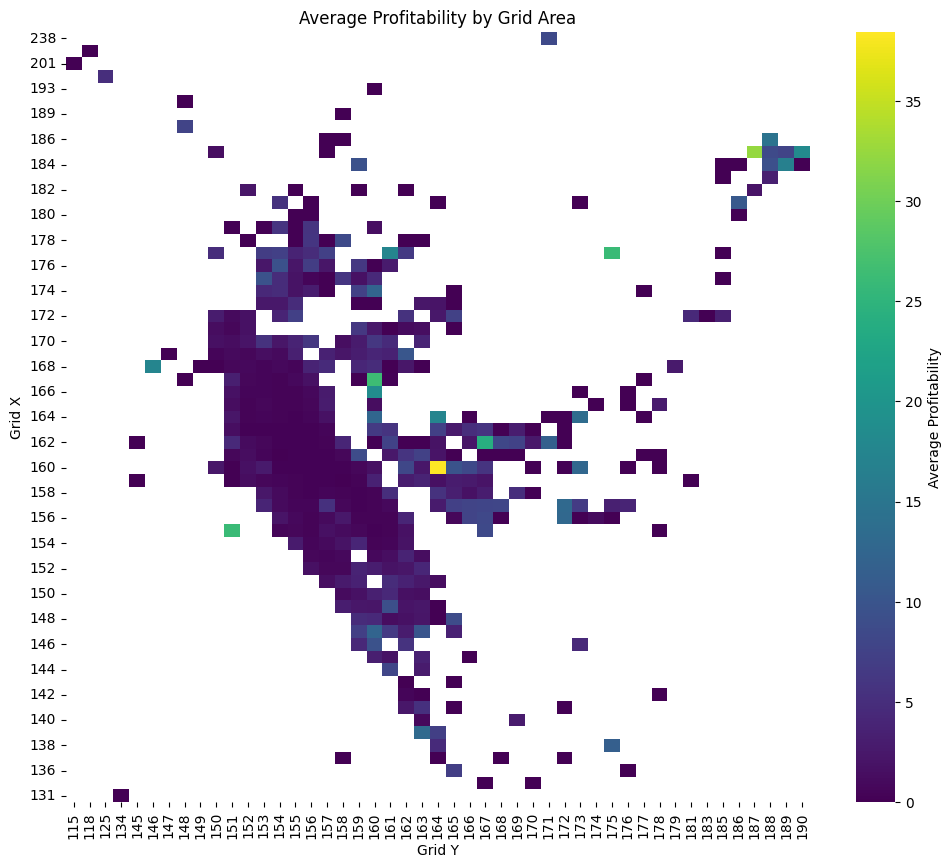

Heatmap of average profitability per grid area displayed.


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate profitability by grid coordinates (average over time windows)
aggregated_profitability = area_profitability_df.groupby(['grid_x', 'grid_y'])['profitability'].mean().reset_index()

# Pivot the data for heatmap
heatmap_data = aggregated_profitability.pivot_table(index='grid_x', columns='grid_y', values='profitability')

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, cmap='viridis', annot=False, fmt=".1f", cbar_kws={'label': 'Average Profitability'})
plt.title('Average Profitability by Grid Area')
plt.xlabel('Grid Y')
plt.ylabel('Grid X')
plt.gca().invert_yaxis() # Invert y-axis to have (0,0) at top-left, matching typical grid representation
plt.show()